In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import os


In [52]:
# Generate a synthetic dataset that looks nice for clustering from make_blobs
# This particular setting has one distinct cluster and 3 clusters placed close
# together.
X, y = make_blobs(
    n_samples=500,
    n_features=2,
    centers=4,
    cluster_std=1,
    center_box=(-10.0, 10.0),
    shuffle=True,
    random_state=42,  # For reproducibility
) 


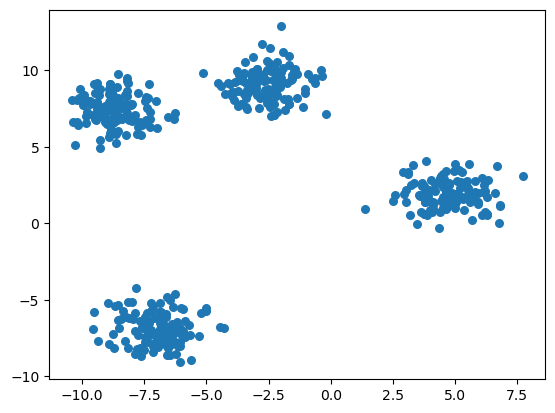

In [53]:
# Let's see how the data looks like
plt.scatter(X[:, 0], X[:, 1], s=30);

In [54]:
# Before we do any thing, let's standardize the data
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

In [55]:
scaled_X[:5]

array([[-0.81539333,  0.58938951],
       [-1.17344434, -1.55328827],
       [ 1.93881064, -0.27298895],
       [ 0.0928425 ,  0.73646712],
       [-0.43397474, -1.60921239]])

In [56]:
kMeans_params = {
    "init": "random",  # Method for initialization
    "n_clusters": 4, 
    "n_init": 10,  # Number of time the k-means algorithm will be run with different centroid seeds
    "max_iter": 300,  # Maximum number of iterations of the k-means algorithm for a single run
    "random_state": 42,  # For reproducibility
}

In [57]:
kmeans = KMeans(**kMeans_params)
kmeans.fit(scaled_X)

c:\Users\APR86\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


KMeans(init='random', n_clusters=4, n_init=10, random_state=42)

In [58]:
# the lowest SSE value
print(kmeans.inertia_)

28.786938978874005


In [59]:
# the final locations of the each centroid
print(kmeans.cluster_centers_)

[[-0.68486276 -1.54855438]
 [-1.00366735  0.72139948]
 [ 1.53895017 -0.15301193]
 [ 0.14957993  0.98016683]]


In [60]:
# cluster labels:
print(kmeans.labels_)

[1 0 2 3 0 0 1 0 2 0 2 3 2 3 0 2 3 1 1 3 2 3 2 1 1 0 0 1 1 3 0 3 3 3 0 0 2
 2 1 1 0 2 3 3 3 2 2 2 0 1 0 3 1 0 2 3 3 1 0 1 1 3 0 1 2 0 0 1 2 0 2 0 0 1
 3 1 3 0 2 3 0 2 0 3 1 1 1 1 2 3 1 0 2 0 2 1 3 2 3 1 2 2 2 1 1 3 3 1 3 1 0
 1 1 1 1 0 2 1 0 0 3 2 0 2 1 2 2 0 0 1 1 2 2 0 2 1 1 1 2 2 0 1 2 2 0 1 1 3
 3 3 0 0 2 2 3 1 3 1 0 0 1 1 2 2 0 3 2 0 1 1 0 3 3 1 1 3 3 0 0 0 3 1 3 3 1
 1 3 2 3 0 0 1 1 0 3 0 3 3 1 0 3 3 0 1 2 1 0 2 2 1 1 0 1 3 3 0 3 1 3 2 2 3
 1 3 2 3 3 0 0 2 0 2 3 0 1 0 3 0 2 2 2 0 3 2 1 1 2 3 3 0 3 3 3 3 2 2 1 3 0
 2 3 3 1 3 0 0 2 3 2 0 3 3 2 1 3 3 3 2 1 0 3 2 2 3 0 3 2 1 2 0 0 3 3 2 1 2
 1 2 0 2 0 1 2 2 3 2 0 0 2 2 0 1 2 2 2 0 1 2 2 2 1 2 2 1 1 1 0 1 1 1 1 1 3
 1 2 1 3 3 1 2 2 2 3 3 0 3 0 3 2 0 0 2 0 1 1 0 1 3 0 3 2 3 0 0 1 2 0 2 2 1
 3 0 2 0 1 2 1 2 1 1 0 1 3 0 1 0 3 0 1 0 1 2 3 3 0 0 2 3 3 3 2 1 0 3 2 2 0
 1 0 0 0 3 2 0 3 2 3 3 2 3 2 3 1 0 2 3 0 1 3 2 2 0 0 0 1 0 2 1 3 3 1 2 1 2
 3 0 0 0 3 2 2 1 3 0 0 0 2 0 3 2 1 2 0 2 3 2 3 2 0 3 1 1 3 3 1 1 3 0 2 0 2
 3 1 1 3 0 1 1 2 1 1 3 1 

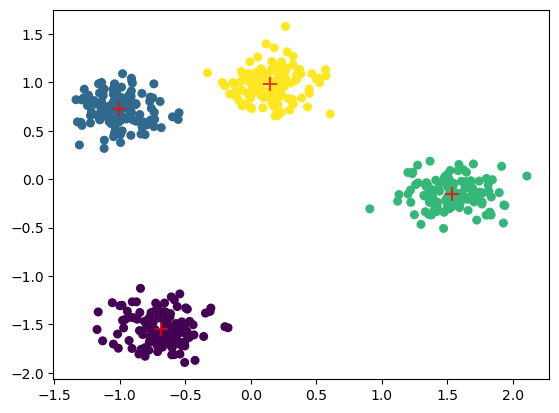

In [61]:
# Now, let's see how the clusters look like
plt.scatter(scaled_X[:, 0], scaled_X[:, 1], c=kmeans.labels_, s=30, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, alpha=0.75, marker='+');  

c:\Users\APR86\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\APR86\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\APR86\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\APR86\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

{2: 558.08510644422, 3: 116.09567852755526, 4: 28.786938978874005, 5: 26.19113104232202, 6: 23.019557612855962, 7: 20.635126042351732, 8: 17.890054158946583, 9: 16.84683989170226}


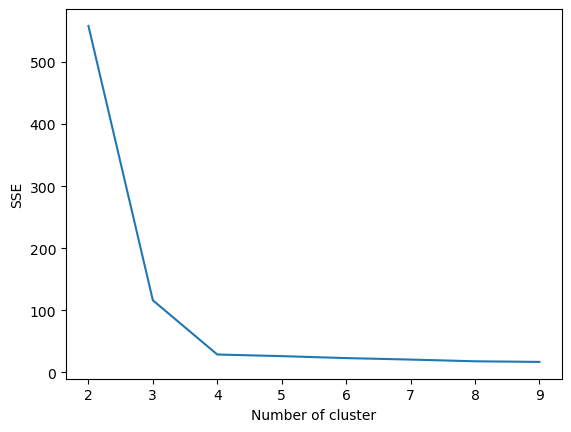

In [62]:
# Let's see if 4 is indeed a good choice for k in this case using elbow method
sse = {}
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000, random_state=42).fit(scaled_X)
    sse[k] = (
        kmeans.inertia_
    )  # Inertia: Sum of distances of samples to their closest cluster center

print(sse)
plt.figure()
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster")
plt.ylabel("SSE")
plt.show()